## What Are Word Embeddings? 

A word embedding is a learned representation for text where words that have the same meaning have a similar representation. 
Word embeddings are in fact a class of techniques where individual words are represented as real-valued vectors in a predefined vector space. Each word is mapped to one vector and the vector values are learned in a way that resembles a neural network, and hence the technique is often lumped into the field of deep learning.

the idea is using a dense distributed representation for each word.

Each word is represented by a real-valued vector, often tens or hundreds of dimensions. This is contrasted to the thousands or millions of dimensions required for sparse word representations, such as a one-hot encoding. 

The distributed representation is learned based on the usage of words. This allows words that are used in similar ways to result in having similar representations, naturally capturing their meaning. This can be contrasted with the crisp but fragile representation in a bag of words model where, unless explicitly managed, different words have different representations, regardless of how they are used. 

There is deeper linguistic theory behind the approach, namely the "distributional hypothesis" by Zellig Harris that could be summarized as: words that have similar context will have similar meanings. 

## Word Embedding Algorithms 

Word embedding methods learn a real-valued vector representation for a predefined fixed sized vocabulary from a corpus of text.

The learning process is either joint with the neural network model on some task, such as document classification, or is an unsupervised process, using document statistics.

three techniques that can be used to learn a word embedding from text data: 


#### Embedding Layer 
An embedding layer, for lack of a better name, is a word embedding that is learned jointly with a neural network model on a specific natural language processing task, such as language modeling or document classification.

It requires that document text be cleaned and prepared such that each word is one-hot encoded. The size of the vector space is specified as part of the model, such as 50, 100, or 300 dimensions. The vectors are initialized with small random numbers. The embedding layer is used on the front end of a neural network and is fit in a supervised way using the Backpropagation algorithm. 

####  Word2Vec 
Word2Vec is a statistical method for efficiently learning a standalone word embedding from a text corpus.

It was developed by Tomas Mikolov as a response to make the neural-network-based training of the embedding more efficient and since then has become the de facto standard for developing pre-trained word embedding.

Additionally, the work involved analysis of the learned vectors and the exploration of vector math on the representations of words. For example, that subtracting the "man-ness" from "King" and adding "women-ness' results in the word "Queen", capturing the analogy "king is to queen as man is to woman" 

Two different learning models were introduced that can be used as part of the word2vec approach to learn the word embedding; they are:

Continuous Bag-of-Words, or CBOW model.
Continuous Skip-Gram Model.
The CBOW model learns the embedding by predicting the current word based on its context. The continuous skip-gram model learns by predicting the surrounding words given a current word.

The continuous skip-gram model learns by predicting the surrounding words given a current word. 
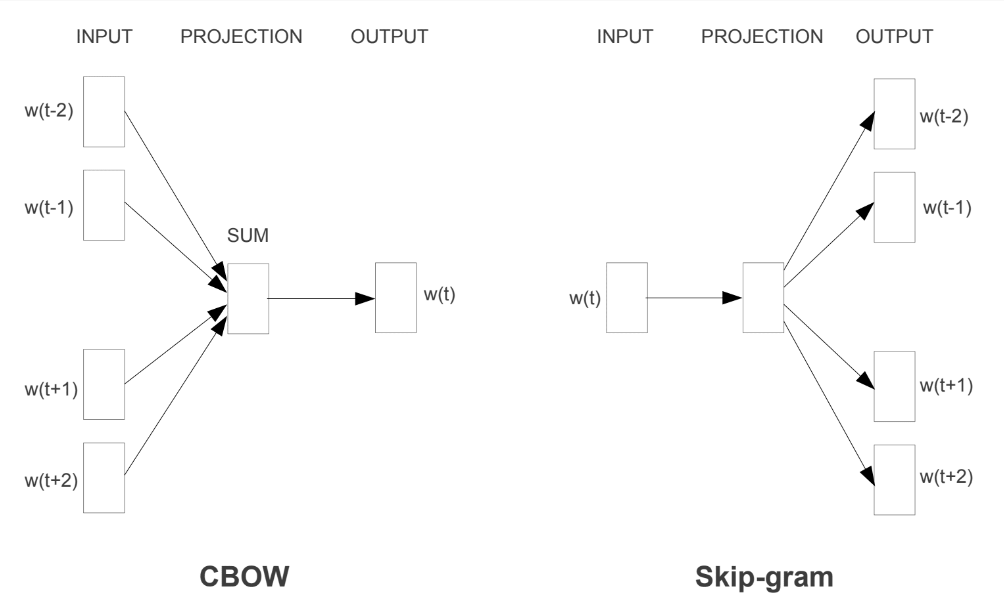 

Both models are focused on learning about words given their local usage context, where the context is defined by a window of neighboring words. This window is a configurable parameter of the model.  

The key benefit of the approach is that high-quality word embeddings can be learned efficiently (low space and time complexity), allowing larger embeddings to be learned (more dimensions) from much larger corpora of text (billions of words). 



#### GloVe 

The Global Vectors for Word Representation, or GloVe, algorithm is an extension to the word2vec method for efficiently learning.

Classical vector space model representations of words were developed using matrix factorization techniques such as Latent Semantic Analysis (LSA) that do a good job of using global text statistics but are not as good as the learned methods like word2vec at capturing meaning and demonstrating it on tasks like calculating analogies (e.g. the King and Queen example above).

GloVe is an approach to marry both the global statistics of matrix factorization techniques like LSA with the local context-based learning in word2vec.

Rather than using a window to define local context, GloVe constructs an explicit word-context or word co-occurrence matrix using statistics across the whole text corpus. The result is a learning model that may result in generally better word embeddings.

## Geometric representation 
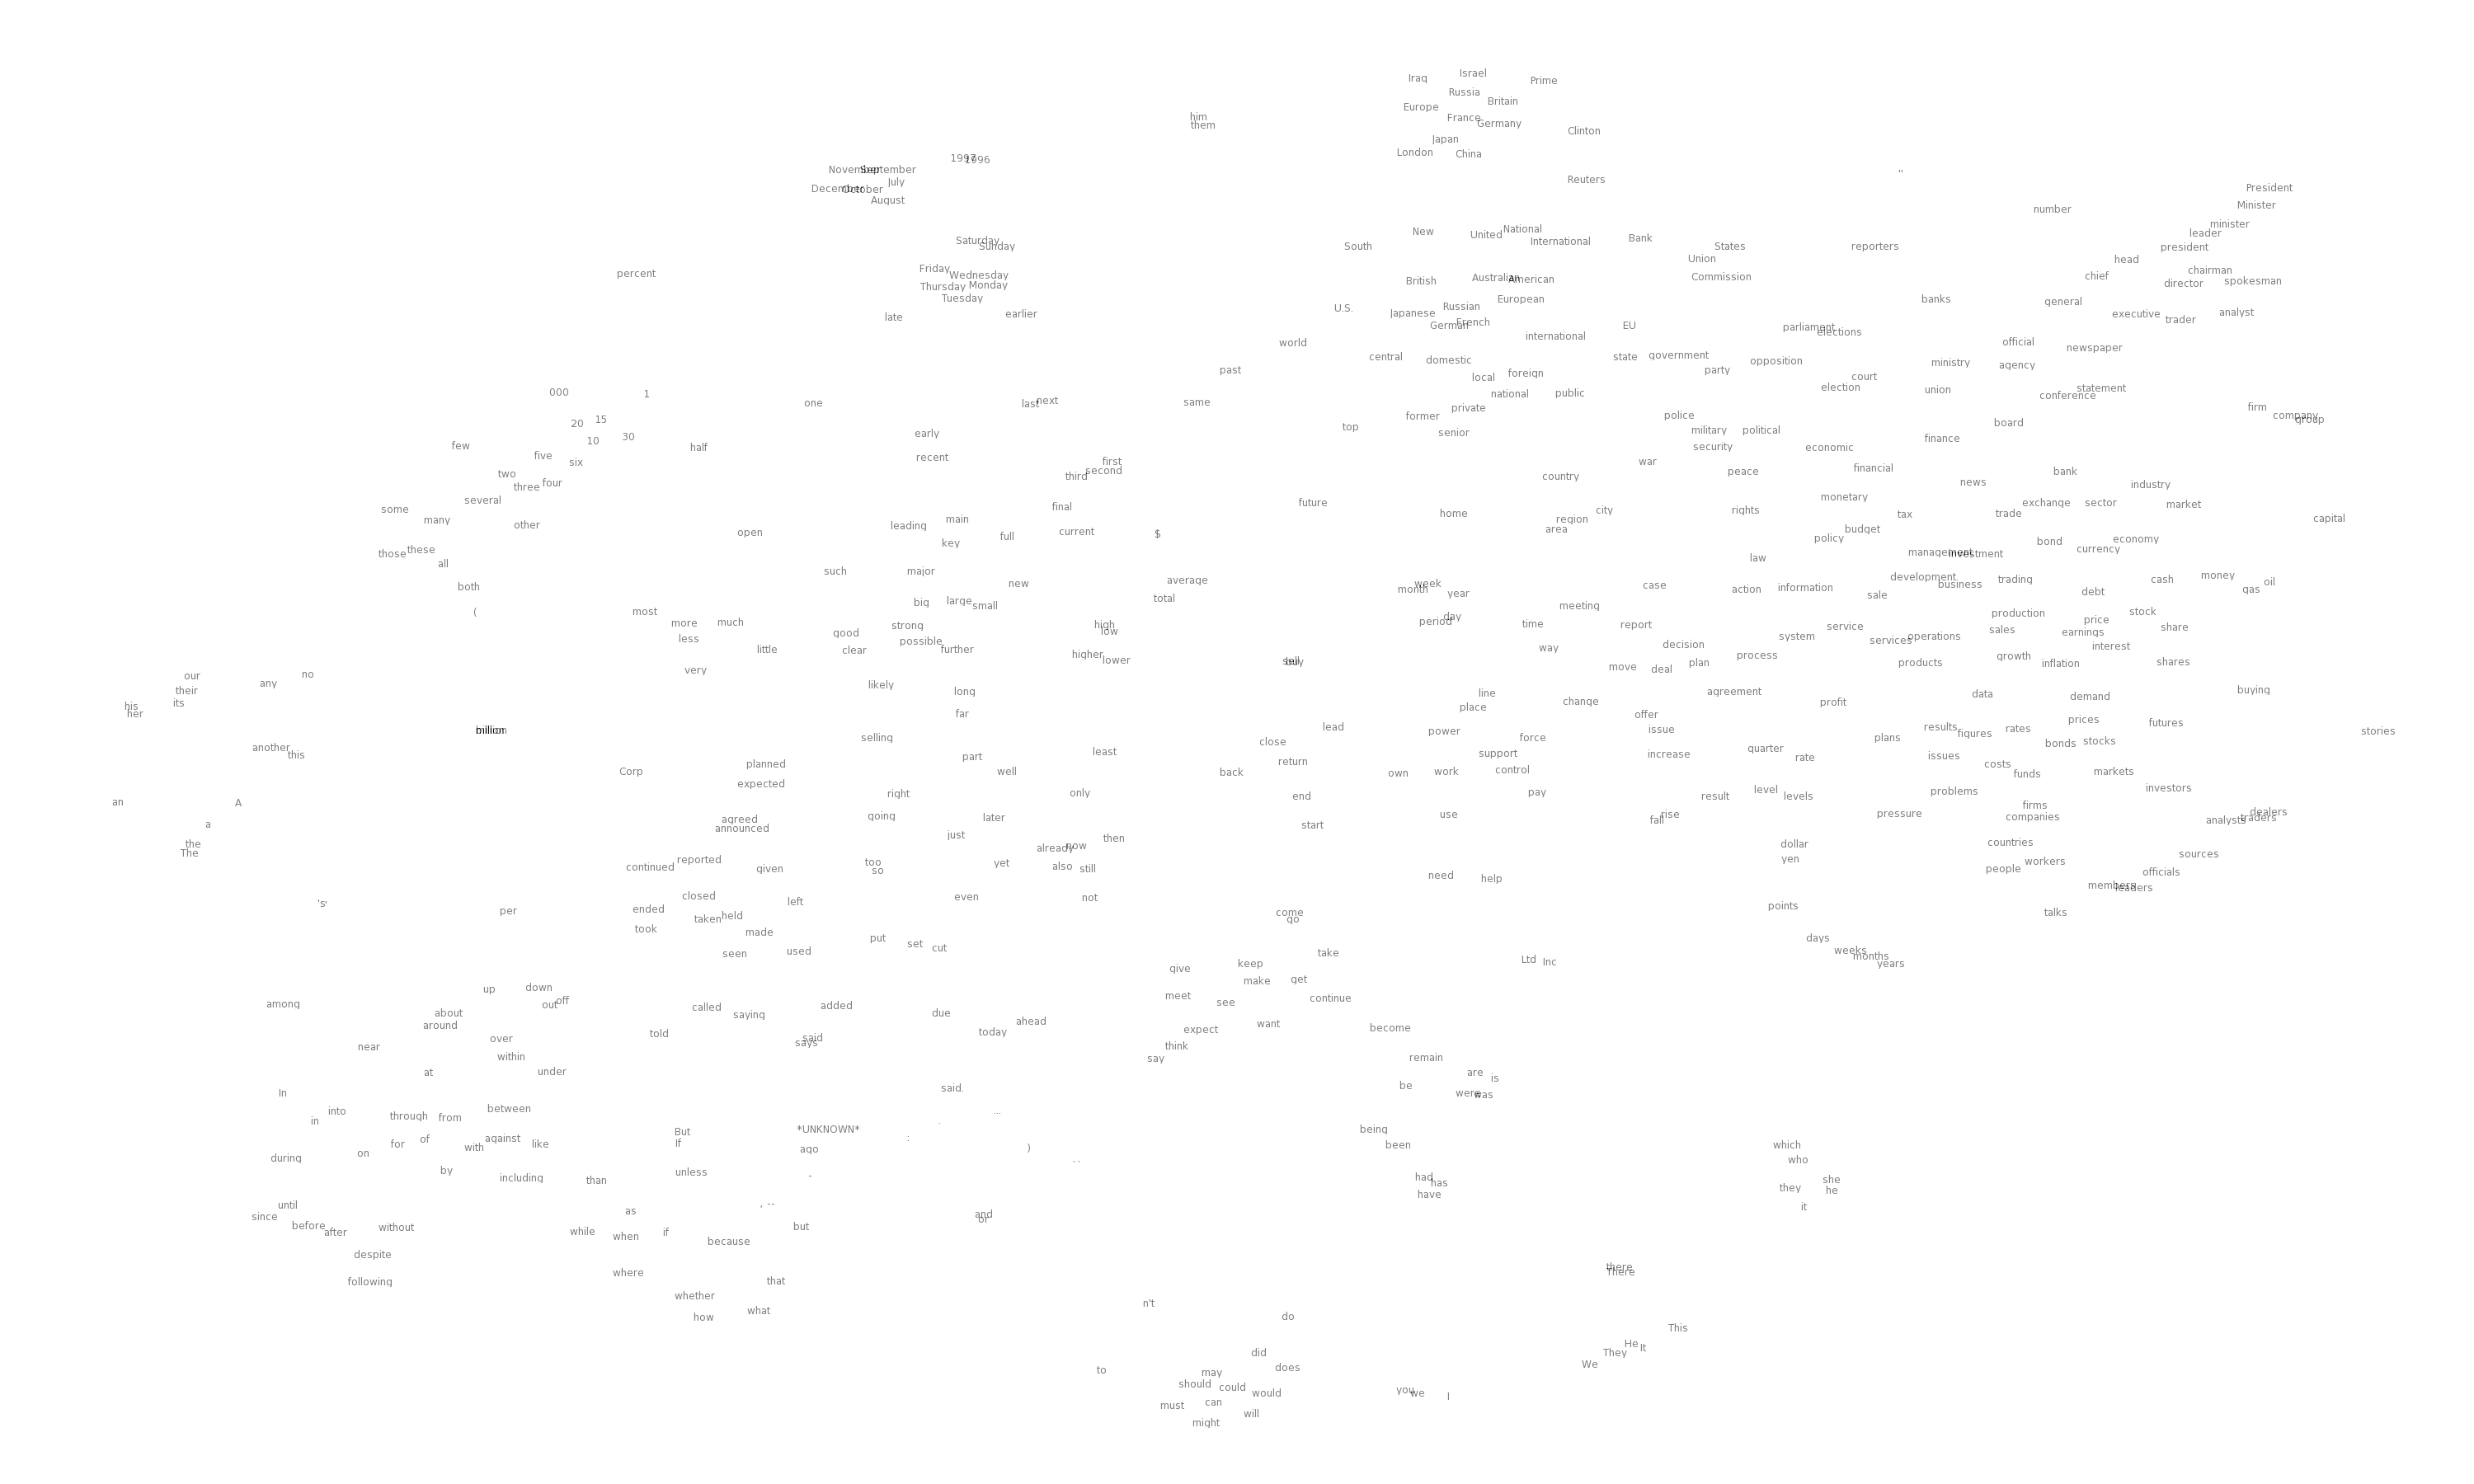 




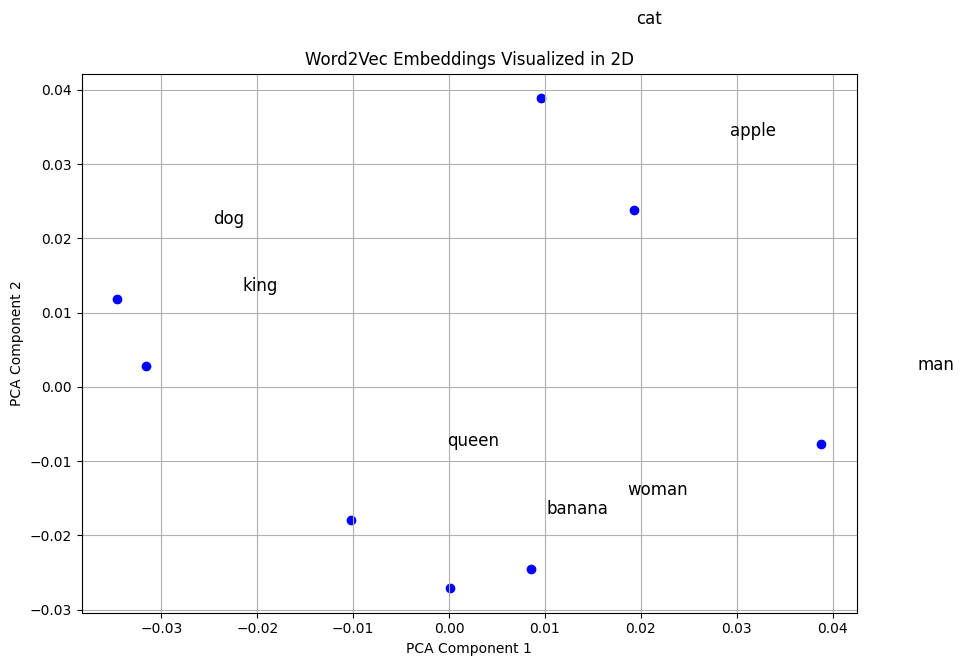

In [4]:
import gensim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec


# Step 1: Prepare the data (a simple example corpus)
sentences = [
    ["king", "queen", "man", "woman", "apple", "banana", "cat", "dog"],
    ["man", "woman", "king", "queen"],
    ["cat", "dog", "apple", "banana"],
    ["king", "man", "queen", "woman"],
    ["apple", "banana", "fruit"],
    ["cat", "pet", "dog", "pet"],
]

# Step 2: Train the Word2Vec model
model = Word2Vec(sentences, vector_size=100, window=3, min_count=1, workers=4)

# Step 3: Extract the word embeddings for specific words in the vocabulary
words = ["king", "queen", "man", "woman", "apple", "banana", "cat", "dog"]

# Create an embedding matrix for these words
embedding_matrix = np.array([model.wv[word] for word in words])

# Step 4: Reduce the dimensionality of the embeddings using PCA or t-SNE
# Using PCA for dimensionality reduction (100D -> 2D)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_matrix)




# Step 5: Visualize the word embeddings in 2D
plt.figure(figsize=(10, 7))

# Plot each word's embedding
for i, word in enumerate(words):
    plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], marker='o', color='blue')
    plt.text(reduced_embeddings[i, 0] + 0.01, reduced_embeddings[i, 1] + 0.01, word, fontsize=12)

plt.title("Word2Vec Embeddings Visualized in 2D")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()
